In [ ]:
library(Seurat)
library(dplyr)
library(ggplot2)


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




In [ ]:
dataset <- readRDS("~/SysBioMed-PLAs/data/datasets/gated_heart_processed.rds")
meta <- dataset@meta.data
name <- "Heart"
OUT_DIR <- paste0("~/FoPra_PLAs/results/exploration_week1/", name , "/")

In [19]:
colnames(meta)

[1] "orig.ident"          "nCount_RNA"          "nFeature_RNA"       
 [4] "nCount_ADT"          "nFeature_ADT"        "sample"             
 [7] "percent.mt"          "percent.ribo"        "percent.hb"         
[10] "mt_outlier_all"      "is_outlier_RNA"      "is_outlier_protein" 
[13] "is_outlier"          "scDblFinder.class"   "scDblFinder.score"  
[16] "celltype"            "HF.etiology"         "Race"               
[19] "Sex"                 "Age"                 "RNA_snn_res.0.8"    
[22] "seurat_clusters"     "RNA_snn_res.0.25"    "RNA.weight"         
[25] "ADT.weight"          "leiden_0.8_totalVI"  "leiden_0.25_totalVI"
[28] "celltype_full"       "lineage"             "pla_status"

In [20]:
summary_table <- dataset@meta.data %>%
  filter(!is.na(pla_status)) %>%
  group_by(sample, lineage) %>%
  summarise(
    n_cells = n(),
    n_PLA = sum(pla_status == "PLA"),
    freq_PLA = n_PLA / n_cells,
    median_nCount_RNA = median(nCount_RNA, na.rm = TRUE),
    median_nCount_ADT = median(nCount_ADT, na.rm = TRUE),
    median_percent_mt = median(percent.mt, na.rm = TRUE),
    .groups = "drop"
  ) %>%
  arrange(desc(freq_PLA))

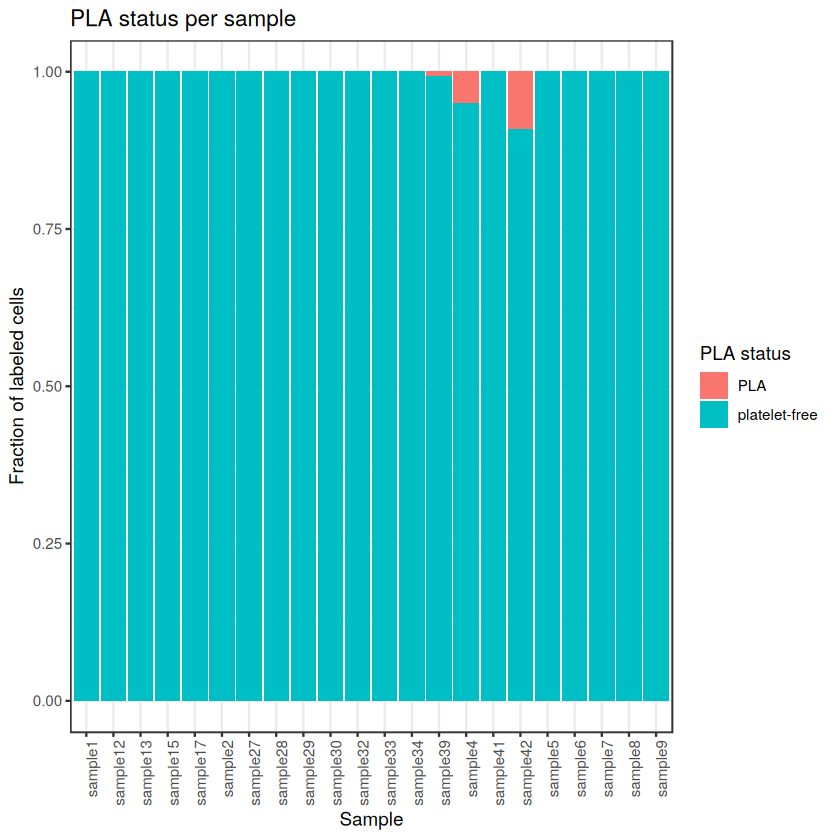

In [21]:
p_donor <- meta %>%
  filter(!is.na(pla_status)) %>%
  group_by(sample, pla_status) %>%
  summarise(n = n(), .groups = "drop") %>%
  group_by(sample) %>%
  mutate(freq = n / sum(n)) %>%
  ggplot(aes(x = sample, y = freq, fill = pla_status)) +
  geom_col() +
  theme_bw() +
  theme(axis.text.x = element_text(angle = 90, hjust = 1)) +
  labs(
    title = "PLA status per sample",
    x = "Sample",
    y = "Fraction of labeled cells",
    fill = "PLA status"
  )

print(p_donor)
ggsave(file.path(OUT_DIR, "01_pla_status_per_sample.png"), p_donor, width = 8, height = 4, dpi = 300)

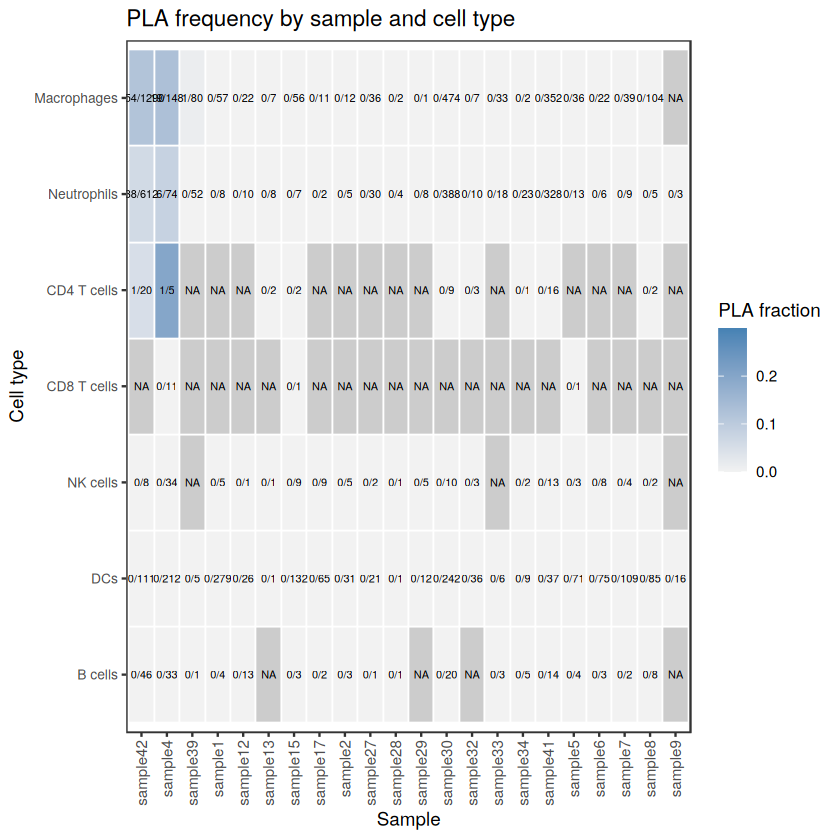

In [ ]:
library(dplyr)
library(tidyr)
library(ggplot2)
library(scales)

# Order donors and cell types in a useful way
sample_order <- summary_table %>%
  group_by(sample) %>%
  summarise(total_PLA = sum(n_PLA, na.rm = TRUE), .groups = "drop") %>%
  arrange(desc(total_PLA)) %>%
  pull(sample)

celltype_order <- summary_table %>%
  group_by(lineage) %>%
  summarise(total_PLA = sum(n_PLA, na.rm = TRUE), .groups = "drop") %>%
  arrange(total_PLA) %>%
  pull(lineage)

plot_df <- summary_table %>%
  mutate(
    sample = factor(sample, levels = sample_order),
    lineage = factor(lineage, levels = celltype_order)
  ) %>%
  complete(
    sample,
    lineage,
    fill = list(
      n_cells = NA_integer_,
      n_PLA = NA_integer_,
      freq_PLA = NA_real_
    )
  ) %>%
  mutate(
    label = ifelse(is.na(n_cells), "NA", paste0(n_PLA, "/", n_cells))
  )

p_all <- ggplot(plot_df, aes(x = sample, y = lineage, fill = freq_PLA)) +
  geom_tile(color = "white", linewidth = 0.35) +
  geom_text(aes(label = label), size = 2.2) +
  scale_fill_gradient(
    low = "grey95",
    high = "steelblue",
    limits = c(0, 0.30),
    oob = scales::squish,
    na.value = "grey80"
  ) +
  theme_bw() +
  theme(
    panel.grid = element_blank(),
    axis.text.x = element_text(angle = 90, hjust = 1, vjust = 0.5),
    axis.text.y = element_text(size = 8),
    legend.position = "right"
  ) +
  labs(
    title = "PLA frequency by sample and cell type",
    x = "Sample",
    y = "Cell type",
    fill = "PLA fraction"
  )

print(p_all)
ggsave(
  file.path(OUT_DIR, "03_pla_frequency_all_celltypes_NA.png"),
  p_all,
  width = 11,
  height = 9,
  dpi = 300
)
